# Lecture 7 — Selecting the latent rank $k$

The rank $k$ is a hyperparameter: it controls the number of latent dimensions used by the matrix-factorization model. This experiment fits several candidate values of $k$ on the same observed entries and evaluates both observed and held-out (missing) reconstruction error.

Because this is a synthetic matrix, the complete matrix is known and the hidden entries can be evaluated against the truth. In a real recommender system, the analogous comparison would use a validation split of known ratings.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True)

In [2]:
def objective_rank_k(Y, U, V, lam):
    mask = ~np.isnan(Y)
    residuals = Y[mask] - (U @ V.T)[mask]
    return 0.5 * np.sum(residuals**2) + 0.5 * lam * (np.sum(U**2) + np.sum(V**2))

def factor_rank_k(Y, k, lam=0.05, max_iter=500, tol=1e-8, seed=1):
    rng = np.random.default_rng(seed)
    n, m = Y.shape
    U = 0.1 * rng.normal(size=(n, k))
    V = 0.1 * rng.normal(size=(m, k))
    I = np.eye(k)
    history = []

    for _ in range(max_iter):
        for a in range(n):
            observed = ~np.isnan(Y[a])
            A = V[observed].T @ V[observed] + lam * I
            b = V[observed].T @ Y[a, observed]
            U[a] = np.linalg.solve(A, b)

        for i in range(m):
            observed = ~np.isnan(Y[:, i])
            A = U[observed].T @ U[observed] + lam * I
            b = U[observed].T @ Y[observed, i]
            V[i] = np.linalg.solve(A, b)

        history.append(objective_rank_k(Y, U, V, lam))
        if len(history) > 1 and abs(history[-1] - history[-2]) < tol:
            break

    return U, V, np.array(history)

In [3]:
# The true matrix has rank 2. We hide roughly 45% of its entries.
rng = np.random.default_rng(42)
n_users, n_movies, k_true = 8, 7, 2
U_true = rng.normal(size=(n_users, k_true))
V_true = rng.normal(size=(n_movies, k_true))
X_true = U_true @ V_true.T

mask = rng.random((n_users, n_movies)) < 0.55
Y_synth = np.where(mask, X_true, np.nan)

results = []
for k in range(1, 6):
    U_hat, V_hat, history = factor_rank_k(Y_synth, k, lam=0.05, seed=1)
    X_hat = U_hat @ V_hat.T

    observed_rmse = np.sqrt(np.mean((X_hat[mask] - X_true[mask])**2))
    missing_rmse = np.sqrt(np.mean((X_hat[~mask] - X_true[~mask])**2))
    results.append({
        'k': k,
        'observed_rmse': observed_rmse,
        'missing_rmse': missing_rmse,
    })

results = pd.DataFrame(results)
print(results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
best_k = results.loc[results['missing_rmse'].idxmin(), 'k']
print(f'\nBest k by held-out RMSE: {best_k}')

 k  observed_rmse  missing_rmse
 1         0.2639        0.5219
 2         0.0263        0.1924
 3         0.0250        0.2647
 4         0.0216        0.3013
 5         0.0213        0.2909

Best k by held-out RMSE: 2


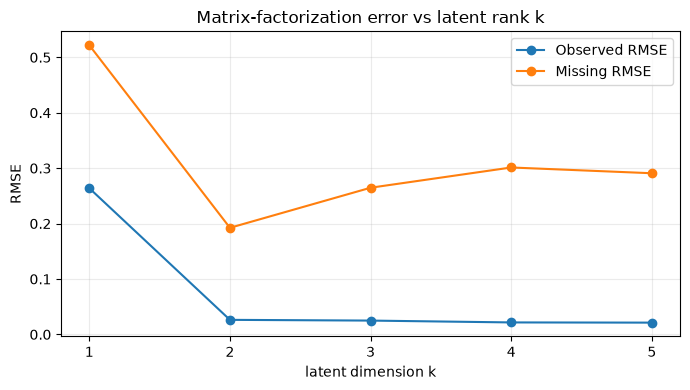

In [4]:
plt.figure(figsize=(7, 4))
plt.plot(results['k'], results['observed_rmse'], marker='o', label='Observed RMSE')
plt.plot(results['k'], results['missing_rmse'], marker='o', label='Missing RMSE')
plt.xlabel('latent dimension k')
plt.ylabel('RMSE')
plt.title('Matrix-factorization error vs latent rank k')
plt.xticks(results['k'])
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Interpretation

The important curve is the **missing/held-out RMSE**. Increasing $k$ gives the model more flexibility, so the observed error generally decreases. But lower observed error does not necessarily mean better predictions for unseen entries.

In this synthetic experiment the true matrix was generated with rank $2$. The held-out RMSE is lowest at $k=2$, while larger ranks start to fit the observed entries slightly better without improving the missing-entry predictions. This illustrates why $k$ should be selected using validation performance rather than by choosing the largest rank.

For a real recommender system, the missing entries are not available as ground truth. Instead, known ratings would be split into training and validation sets, and the rank would be selected by the validation score.